In [23]:
#Import libraries
import sys
import os
import numpy as np
import pandas as pd
import sys
import sqlite3
from pathlib import Path
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap


#Set up graficos
%matplotlib inline
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

ROOT = Path().resolve().parent  #
DB_PATH = ROOT / "hotel_kpi.db"   

conn = sqlite3.connect(DB_PATH)

pnl_eda = pd.read_sql_query("SELECT * FROM pnl", conn)
hotels_eda = pd.read_sql_query("SELECT * FROM hotels", conn)

conn.close()

### Data integrity

In [24]:
print("--- 1. Integridad de pnl_eda ---")
display(pnl_eda.isnull().sum()[pnl_eda.isnull().sum() > 0])

print("\n--- 2. Integridad de hotel_eda ---")
display(hotels_eda.isnull().sum())

--- 1. Integridad de pnl_eda ---


AR    465
dtype: int64


--- 2. Integridad de hotel_eda ---


HOTEL                 0
CONTINENTE            0
PAIS                  0
CATEGORIA             2
TOTAL_HABITACIONES    0
dtype: int64

In [25]:
print("--- 1. Visualizacion de primeros y utlitmos registros de pnl ---")
display(pnl_eda.head())

display(pnl_eda.tail())


print("--- 1. Visualizacion de primeros y utlitmos registros de hotes ---")
display(hotels_eda.head())
display(hotels_eda.tail())




--- 1. Visualizacion de primeros y utlitmos registros de pnl ---


,HOTEL,ANIO,MES,ESCENARIO,RN,HABITACIONES,ROOMS_REV_ALOJAMIENTO,ROOMS_REV_UPGRADES,ROOMS_REV_OTROS,ROOMS_REVENUE,...,FB_COST,FB_PERSONNEL,FB_OTHER_EXPENSES,FB_OPEX,OPERATING_EXPENSES,ROOMS_PROFIT,FB_PROFIT,TOTAL_DEPT_PROFIT,UNDISTRIB_OPEX,GOP
0,Hotel Alhambra,2025,1,BUDGET,18428,20882,5327177.62,120876.32,1759.76,5449813.70,...,-928620.99,-441504.22,-89754.22,-1459879.43,-2230900.73,4678792.40,366338.75,5104178.39,-1776453.67,3327724.72
1,Hotel Alhambra,2025,1,REAL,17763,19260,4606182.16,110647.76,28182.95,4745012.87,...,-738593.63,-392120.05,-71984.60,-1202698.28,-1963684.46,3984026.69,615792.62,4674800.61,-1375963.32,3298837.29
2,Hotel Alhambra,2025,2,BUDGET,16465,22707,4058131.90,107370.64,870.36,4166372.90,...,-818497.41,-483422.38,-89145.55,-1391065.33,-2156690.84,3400747.39,378358.41,3844368.43,-1861579.51,1982788.92
3,Hotel Alhambra,2025,2,REAL,15389,19411,3480297.31,56990.29,16894.97,3554182.56,...,-745140.40,-448643.17,-80014.63,-1273798.19,-2021817.71,2806163.05,259925.51,3136997.15,-1324902.73,1812094.41
4,Hotel Alhambra,2025,3,BUDGET,16626,23112,2968584.16,90735.73,1405.08,3060724.97,...,-753950.07,-445228.80,-71085.87,-1270264.74,-1911277.04,2419712.67,314124.20,2899367.26,-1683670.69,1215696.57


,HOTEL,ANIO,MES,ESCENARIO,RN,HABITACIONES,ROOMS_REV_ALOJAMIENTO,ROOMS_REV_UPGRADES,ROOMS_REV_OTROS,ROOMS_REVENUE,...,FB_COST,FB_PERSONNEL,FB_OTHER_EXPENSES,FB_OPEX,OPERATING_EXPENSES,ROOMS_PROFIT,FB_PROFIT,TOTAL_DEPT_PROFIT,UNDISTRIB_OPEX,GOP
1291,Hotel Zenith,2026,10,REAL,0,0,0.00,0.00,0.0,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
1292,Hotel Zenith,2026,11,BUDGET,5935,9131,404153.33,12174.23,0.0,416327.56,...,-95238.51,-67760.12,-19252.02,-182250.66,-327105.81,271472.41,41507.92,1157682.20,-340367.83,817314.37
1293,Hotel Zenith,2026,11,REAL,0,0,0.00,0.00,0.0,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
1294,Hotel Zenith,2026,12,BUDGET,4032,6953,275606.10,8970.49,0.0,284576.59,...,-60298.05,-49928.51,-18179.15,-128405.70,-230901.71,182080.58,17582.51,929604.13,-260873.91,668730.22
1295,Hotel Zenith,2026,12,REAL,0,0,0.00,0.00,0.0,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00


--- 1. Visualizacion de primeros y utlitmos registros de hotes ---


,HOTEL,CONTINENTE,PAIS,CATEGORIA,TOTAL_HABITACIONES
0,Hotel Aurora,EUROPA,ESP,5*,151
1,Hotel Boreal,EUROPA,ESP,5*,379
2,Hotel Borealis,EUROPA,ESP,NaN,119
3,Hotel Celeste,EUROPA,ESP,5*,111
4,Hotel Cosmos,EUROPA,ESP,5*,415


,HOTEL,CONTINENTE,PAIS,CATEGORIA,TOTAL_HABITACIONES
24,Hotel Vega Mar,EUROPA,ESP,5*,191
25,Hotel Windrose,AMERICA,MEX,5*,510
26,Hotel Xenon,AMERICA,MEX,5*,1554
27,Hotel Yaris,EUROPA,MEX,5*,13
28,Hotel Zenith,AMERICA,RD,4*,271


In [26]:
print("--- 1. Variables pnl ---")
display(pnl_eda.info())



--- 1. Variables pnl ---
<class 'pandas.DataFrame'>
RangeIndex: 1296 entries, 0 to 1295
Data columns (total 35 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   HOTEL                  1296 non-null   str    
 1   ANIO                   1296 non-null   int64  
 2   MES                    1296 non-null   int64  
 3   ESCENARIO              1296 non-null   str    
 4   RN                     1296 non-null   int64  
 5   HABITACIONES           1296 non-null   int64  
 6   ROOMS_REV_ALOJAMIENTO  1296 non-null   float64
 7   ROOMS_REV_UPGRADES     1296 non-null   float64
 8   ROOMS_REV_OTROS        1296 non-null   float64
 9   ROOMS_REVENUE          1296 non-null   float64
 10  FOOD_REVENUE           1296 non-null   float64
 11  BEVERAGE_REVENUE       1296 non-null   float64
 12  BANQUETS_REVENUE       1296 non-null   float64
 13  FB_PENSION             1296 non-null   float64
 14  DAY_PASS               1296 non-null   flo

None

### EDA de hotels

In [27]:
# Determinar nivel de poblamiento
eda_poblacion = pd.DataFrame({
    'Registros_OK': hotels_eda.notnull().sum(),
    'Nulos': hotels_eda.isnull().sum(),
    'Poblacion_%': (hotels_eda.notnull().sum() / len(hotels_eda) * 100).round(2),
    'Dtype': hotels_eda.dtypes
})

variables_pobladas = eda_poblacion[eda_poblacion['Poblacion_%'] > 0].sort_values('Poblacion_%', ascending=False)
variables_vacias = eda_poblacion[eda_poblacion['Poblacion_%'] == 0]

print(f"RESUMEN:")
print(f"Total de columnas: {len(eda_poblacion)}")
print(f"Columnas con datos: {len(variables_pobladas)}")
print(f"Columnas 100% vacías: {len(variables_vacias)}")

if not variables_vacias.empty:
    print(f"- Lista de vacías: {variables_vacias.index.tolist()}")

RESUMEN:
Total de columnas: 5
Columnas con datos: 5
Columnas 100% vacías: 0


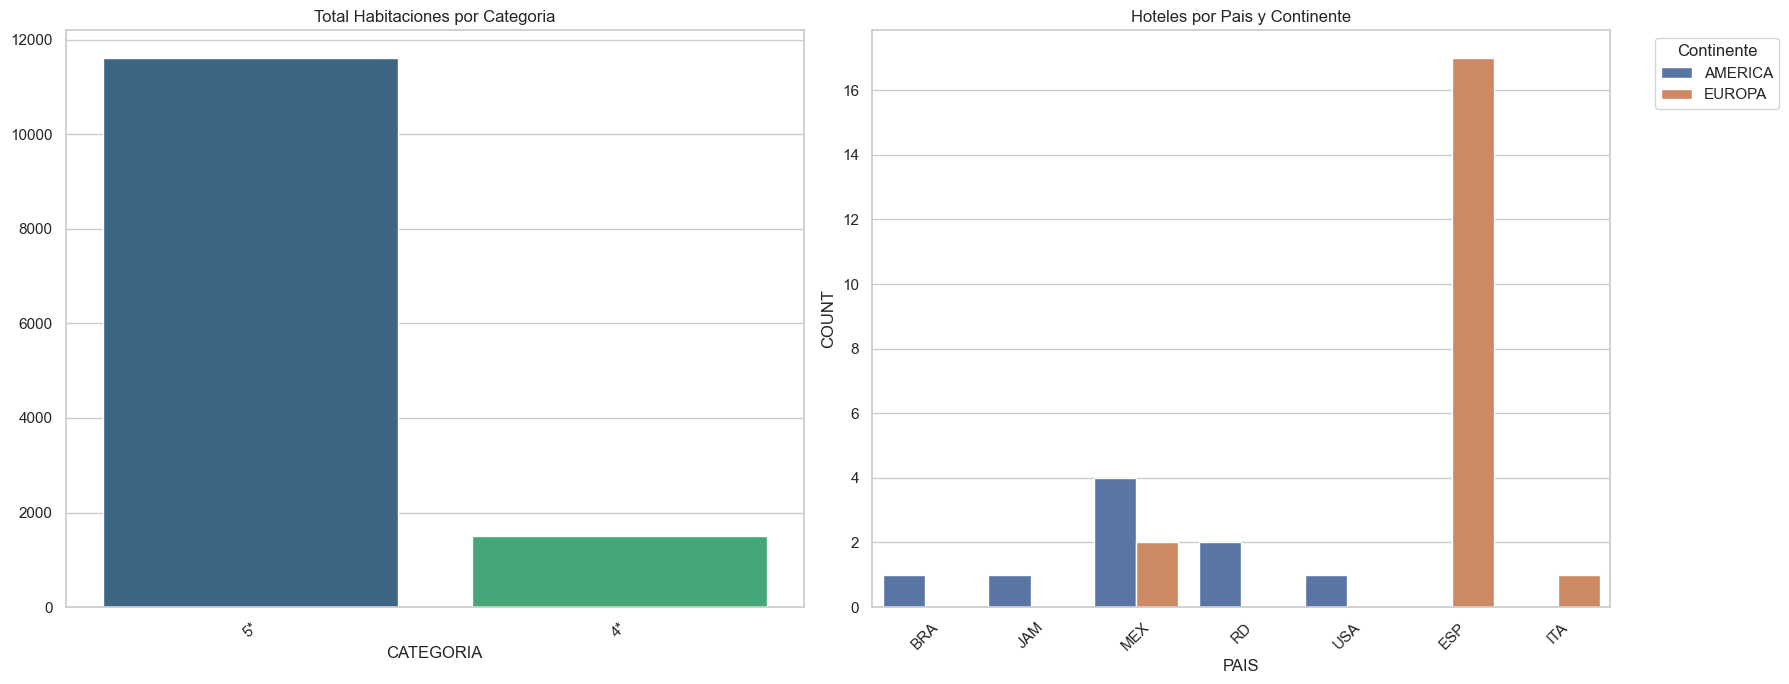

In [28]:
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

#Categoria vs habitaciones
cat_hab = hotels_eda.groupby('CATEGORIA')['TOTAL_HABITACIONES'].sum().sort_values(ascending=False)
sns.barplot(
    x=cat_hab.index, 
    y=cat_hab.values, 
    hue=cat_hab.index, 
    legend=False, 
    palette='viridis', 
    ax=axes[0]
)
axes[0].set_title('Total Habitaciones por Categoria')
axes[0].tick_params(axis='x', rotation=45)

# Pais vs Continente
pais_cont = hotels_eda.groupby(['CONTINENTE', 'PAIS']).size().reset_index(name='COUNT')
sns.barplot(
    data=pais_cont, 
    x='PAIS', 
    y='COUNT', 
    hue='CONTINENTE', 
    ax=axes[1]
)
axes[1].set_title('Hoteles por Pais y Continente')
axes[1].tick_params(axis='x', rotation=45)
axes[1].legend(title='Continente', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

### Visualizacion de principales metricas OPERATING_REVENUE, GOP, RN

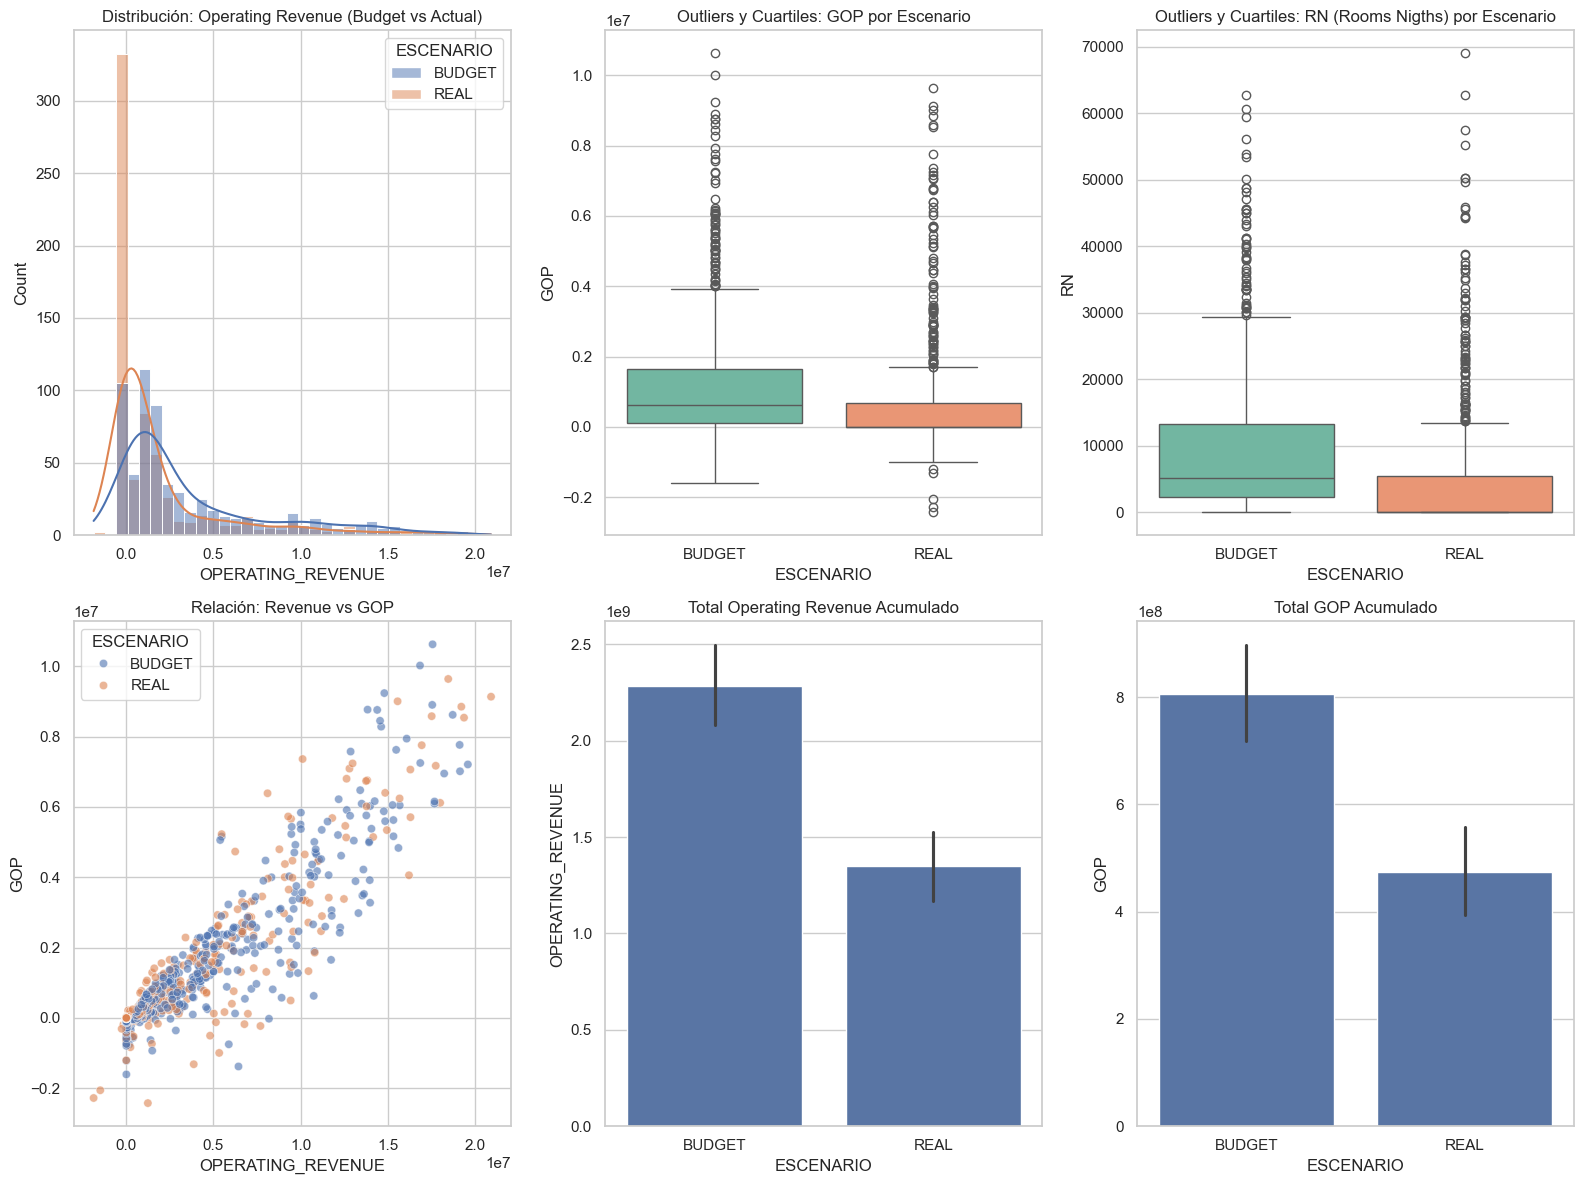

In [29]:
# Configuración de la cuadrícula 2x2
fig, ax = plt.subplots(2, 3, figsize=(16, 12))

#Comparación de Distribución de Revenue
sns.histplot(data=pnl_eda, x='OPERATING_REVENUE', hue='ESCENARIO', kde=True, ax=ax[0, 0])
ax[0, 0].set_title('Distribución: Operating Revenue (Budget vs Actual)')

#Comparación de Outliers y Cuartiles de GOP
sns.boxplot(data=pnl_eda, x='ESCENARIO', y='GOP', hue='ESCENARIO', palette='Set2', ax=ax[0, 1])
ax[0, 1].set_title('Outliers y Cuartiles: GOP por Escenario')

#Relación Revenue vs GOP por Escenario
sns.scatterplot(data=pnl_eda, x='OPERATING_REVENUE', y='GOP', hue='ESCENARIO', alpha=0.6, ax=ax[1, 0])
ax[1, 0].set_title('Relación: Revenue vs GOP')

# 3. Comparación de Totales (Promedio)
sns.barplot(data=pnl_eda, x='ESCENARIO', y='OPERATING_REVENUE', ax=ax[1, 1], estimator=sum)
ax[1, 1].set_title('Total Operating Revenue Acumulado')

#Comparación de Outliers y Cuartiles de RN
sns.boxplot(data=pnl_eda, x='ESCENARIO', y='RN', hue='ESCENARIO', palette='Set2', ax=ax[0, 2])
ax[0, 2].set_title('Outliers y Cuartiles: RN (Rooms Nigths) por Escenario')

# 3. Comparación de Totales (Promedio)
sns.barplot(data=pnl_eda, x='ESCENARIO', y='GOP', ax=ax[1, 2], estimator=sum)
ax[1, 2].set_title('Total GOP Acumulado')


plt.tight_layout()
plt.show()


### Analisis de estacionalidad y cierres
#### 1. Revision de cierres
Se prueban 2 definiciones distintas para determinar si un hotel esta abierto

1. Rooms Nights >0 | Operative Revenue >0 : Un hotel se considera abierto si exsite cualquier señal de actividad economica (Huespedes o ingresos)

2. Rooms Nights >0 . Un hotel se considera abierto únicamente cuando presenta actividad operativa , definida como Room Nights mayores a cero o ingresos operativos distintos de cero.


#### Analisis de Definicion 1 : Rooms Nights >0 | Operative Revenue >0 

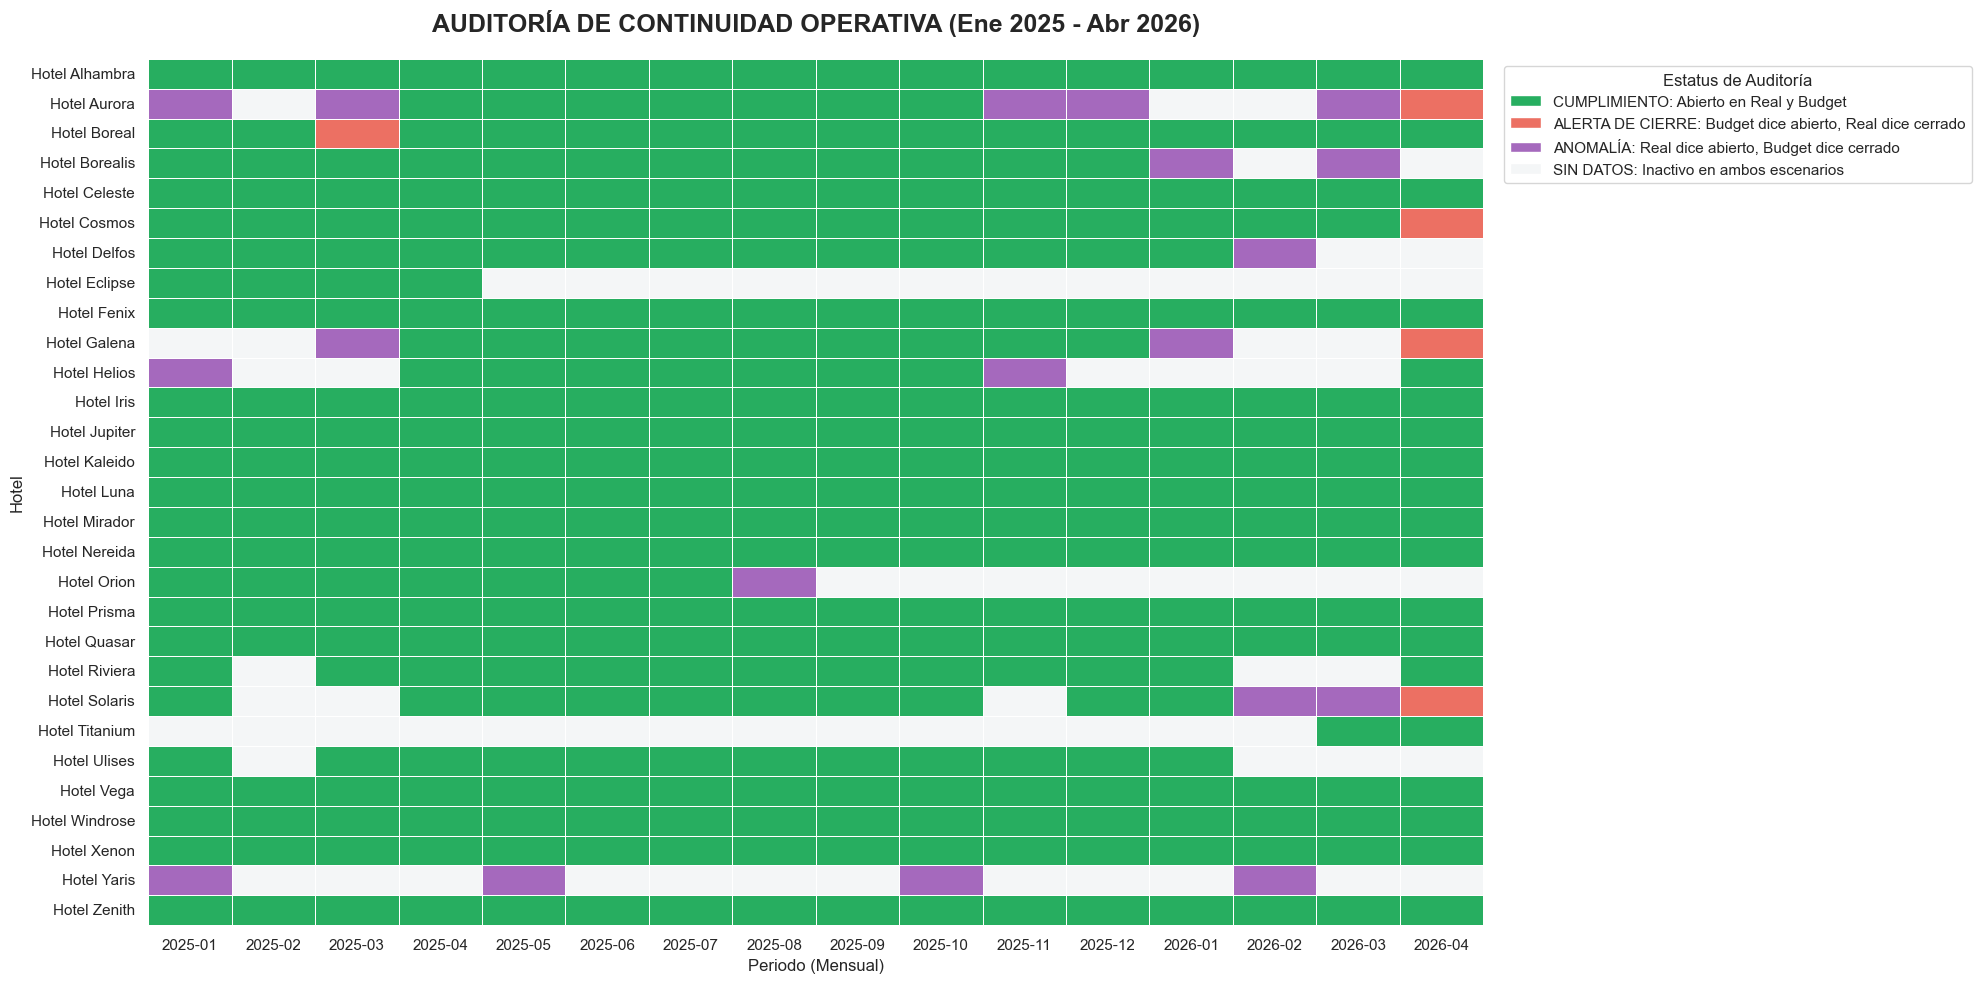

REPORTE DISCREPANCIAS DE PERIODOS POR HOTEL


,COINCIDEN (Real & Budget),SOLO BUDGET (Falta en Real),SOLO REAL (Falta en Budget),INACTIVOS
HOTEL,,,,
Hotel Aurora,"2025-04, 2025-05, 2025-06, 2025-07, 2025-08, 2...",2026-04,"2025-01, 2025-03, 2025-11, 2025-12, 2026-03","2025-02, 2026-01, 2026-02"
Hotel Boreal,"2025-01, 2025-02, 2025-04, 2025-05, 2025-06, 2...",2025-03,,
Hotel Borealis,"2025-01, 2025-02, 2025-03, 2025-04, 2025-05, 2...",,"2026-01, 2026-03","2026-02, 2026-04"
Hotel Cosmos,"2025-01, 2025-02, 2025-03, 2025-04, 2025-05, 2...",2026-04,,
Hotel Delfos,"2025-01, 2025-02, 2025-03, 2025-04, 2025-05, 2...",,2026-02,"2026-03, 2026-04"
Hotel Galena,"2025-04, 2025-05, 2025-06, 2025-07, 2025-08, 2...",2026-04,"2025-03, 2026-01","2025-01, 2025-02, 2026-02, 2026-03"
Hotel Helios,"2025-04, 2025-05, 2025-06, 2025-07, 2025-08, 2...",,"2025-01, 2025-11","2025-02, 2025-03, 2025-12, 2026-01, 2026-02, 2..."
Hotel Orion,"2025-01, 2025-02, 2025-03, 2025-04, 2025-05, 2...",,2025-08,"2025-09, 2025-10, 2025-11, 2025-12, 2026-01, 2..."
Hotel Solaris,"2025-01, 2025-04, 2025-05, 2025-06, 2025-07, 2...",2026-04,"2026-02, 2026-03","2025-02, 2025-03, 2025-11"


REPORTE INACTIVOS DE PERIODOS POR HOTEL


,COINCIDEN (Real & Budget),SOLO BUDGET (Falta en Real),SOLO REAL (Falta en Budget),INACTIVOS
HOTEL,,,,
Hotel Aurora,"2025-04, 2025-05, 2025-06, 2025-07, 2025-08, 2...",2026-04,"2025-01, 2025-03, 2025-11, 2025-12, 2026-03","2025-02, 2026-01, 2026-02"
Hotel Borealis,"2025-01, 2025-02, 2025-03, 2025-04, 2025-05, 2...",,"2026-01, 2026-03","2026-02, 2026-04"
Hotel Delfos,"2025-01, 2025-02, 2025-03, 2025-04, 2025-05, 2...",,2026-02,"2026-03, 2026-04"
Hotel Eclipse,"2025-01, 2025-02, 2025-03, 2025-04",,,"2025-05, 2025-06, 2025-07, 2025-08, 2025-09, 2..."
Hotel Galena,"2025-04, 2025-05, 2025-06, 2025-07, 2025-08, 2...",2026-04,"2025-03, 2026-01","2025-01, 2025-02, 2026-02, 2026-03"
Hotel Helios,"2025-04, 2025-05, 2025-06, 2025-07, 2025-08, 2...",,"2025-01, 2025-11","2025-02, 2025-03, 2025-12, 2026-01, 2026-02, 2..."
Hotel Orion,"2025-01, 2025-02, 2025-03, 2025-04, 2025-05, 2...",,2025-08,"2025-09, 2025-10, 2025-11, 2025-12, 2026-01, 2..."
Hotel Riviera,"2025-01, 2025-03, 2025-04, 2025-05, 2025-06, 2...",,,"2025-02, 2026-02, 2026-03"
Hotel Solaris,"2025-01, 2025-04, 2025-05, 2025-06, 2025-07, 2...",2026-04,"2026-02, 2026-03","2025-02, 2025-03, 2025-11"


In [30]:

#  Prepare dates and identificators
pnl_eda['FECHA_INT'] = pnl_eda['ANIO'] * 100 + pnl_eda['MES']
pnl_eda['FECHA_STR'] = pnl_eda['ANIO'].astype(str) + "-" + pnl_eda['MES'].astype(str).str.zfill(2)

pnl_filtered = pnl_eda[pnl_eda['FECHA_INT'] <= 202604].copy()

# Definición: IS_OPEN
pnl_filtered["IS_OPEN"] =  ((pnl_filtered["RN"] > 0) | (pnl_filtered["OPERATING_REVENUE"] > 0))

# Create matrices budget & real to headpmap (pivot)
pivot_real = pnl_filtered[pnl_filtered['ESCENARIO'] == 'REAL'].pivot_table(
    index='HOTEL', columns='FECHA_STR', values='IS_OPEN', aggfunc='max'
).fillna(0)

pivot_budget = pnl_filtered[pnl_filtered['ESCENARIO'] == 'BUDGET'].pivot_table(
    index='HOTEL', columns='FECHA_STR', values='IS_OPEN', aggfunc='max'
).fillna(0)

# Audit
# 3: OK (Verde), 2: Cierre (Rojo), 1: Sin Presupuesto (Morado), 0: Inactivo (Gris)
def audit_logic(h, m):
    in_real = pivot_real.loc[h, m] if m in pivot_real.columns and h in pivot_real.index else 0
    in_bud = pivot_budget.loc[h, m] if m in pivot_budget.columns and h in pivot_budget.index else 0
    
    if in_real and in_bud: return 3   # Coinciden abiertos
    if in_bud and not in_real: return 2 # Planificado pero cerrado en Real
    if in_real and not in_bud: return 1 # Operando pero no planificado
    return 0 # Inactivo en ambos

# Final matrix for audit
audit_matrix = pd.DataFrame(index=pivot_real.index.union(pivot_budget.index), columns=pivot_real.columns)
for h in audit_matrix.index:
    for m in audit_matrix.columns:
        audit_matrix.loc[h, m] = audit_logic(h, m)

audit_matrix = audit_matrix.astype(float)

plt.figure(figsize=(20, 10))
# Colores: [Gris, Morado, Rojo, Verde]
colors = ['#f4f6f7', '#a569bd', '#ec7063', '#27ae60']
sns.heatmap(audit_matrix, cmap=ListedColormap(colors), cbar=False, linewidths=0.7, linecolor='white')

plt.title('AUDITORÍA DE CONTINUIDAD OPERATIVA (Ene 2025 - Abr 2026)', fontsize=18, fontweight='bold', pad=20)
plt.xlabel('Periodo (Mensual)', fontsize=12)
plt.ylabel('Hotel', fontsize=12)

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#27ae60', label='CUMPLIMIENTO: Abierto en Real y Budget'),
    Patch(facecolor='#ec7063', label='ALERTA DE CIERRE: Budget dice abierto, Real dice cerrado'),
    Patch(facecolor='#a569bd', label='ANOMALÍA: Real dice abierto, Budget dice cerrado'),
    Patch(facecolor='#f4f6f7', label='SIN DATOS: Inactivo en ambos escenarios')
]
plt.legend(handles=legend_elements, bbox_to_anchor=(1.01, 1), loc='upper left', title="Estatus de Auditoría")

plt.tight_layout()
plt.show()

#Meses abierto
def obtener_periodos(row, codigo):
    return ", ".join(row[row == codigo].index.tolist())
detalle_periodos = pd.DataFrame(index=audit_matrix.index)
detalle_periodos['COINCIDEN (Real & Budget)'] = audit_matrix.apply(lambda r: obtener_periodos(r, 3), axis=1)
detalle_periodos['SOLO BUDGET (Falta en Real)'] = audit_matrix.apply(lambda r: obtener_periodos(r, 2), axis=1)
detalle_periodos['SOLO REAL (Falta en Budget)'] = audit_matrix.apply(lambda r: obtener_periodos(r, 1), axis=1)
detalle_periodos['INACTIVOS'] = audit_matrix.apply(lambda r: obtener_periodos(r, 0), axis=1)
#Filtrar discrepancias
reporte_discrepancias = detalle_periodos[
    (detalle_periodos['SOLO BUDGET (Falta en Real)'] != "") | 
    (detalle_periodos['SOLO REAL (Falta en Budget)'] != "")
]

#Filtrar inactivos
reporte_inactivos = detalle_periodos[
    (detalle_periodos['INACTIVOS'] != "")
]
print("REPORTE DISCREPANCIAS DE PERIODOS POR HOTEL")
display(reporte_discrepancias)

print("REPORTE INACTIVOS DE PERIODOS POR HOTEL")
display(reporte_inactivos)


Se considera que esta definicion puede incluir falsos positivos, como ajustes contables, reclasificaciones o ingresos no operativos mal mapeados

#### Analisis de Definicion de abierto 2 : Rooms Nights >0 

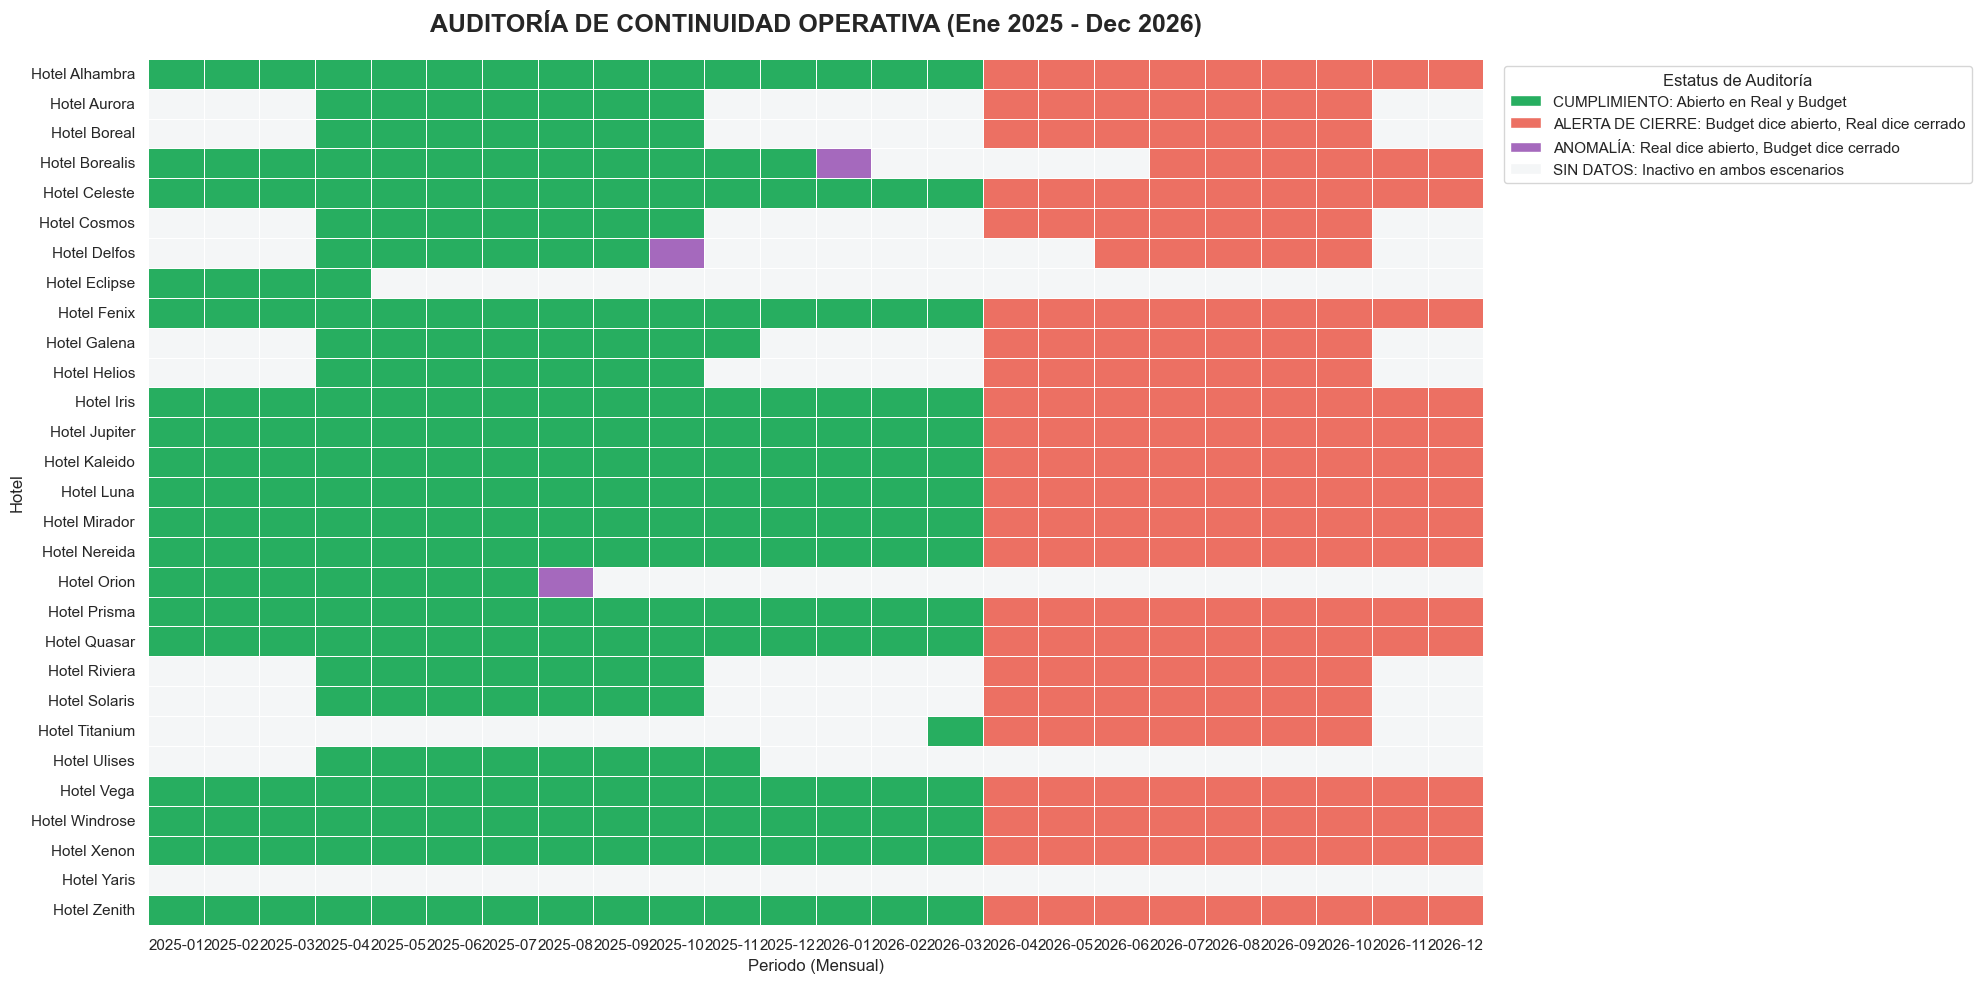

REPORTE DISCREPANCIAS DE PERIODOS POR HOTEL


,COINCIDEN (Real & Budget),SOLO BUDGET (Falta en Real),SOLO REAL (Falta en Budget),INACTIVOS
HOTEL,,,,
Hotel Alhambra,"2025-01, 2025-02, 2025-03, 2025-04, 2025-05, 2...","2026-04, 2026-05, 2026-06, 2026-07, 2026-08, 2...",,
Hotel Aurora,"2025-04, 2025-05, 2025-06, 2025-07, 2025-08, 2...","2026-04, 2026-05, 2026-06, 2026-07, 2026-08, 2...",,"2025-01, 2025-02, 2025-03, 2025-11, 2025-12, 2..."
Hotel Boreal,"2025-04, 2025-05, 2025-06, 2025-07, 2025-08, 2...","2026-04, 2026-05, 2026-06, 2026-07, 2026-08, 2...",,"2025-01, 2025-02, 2025-03, 2025-11, 2025-12, 2..."
Hotel Borealis,"2025-01, 2025-02, 2025-03, 2025-04, 2025-05, 2...","2026-07, 2026-08, 2026-09, 2026-10, 2026-11, 2...",2026-01,"2026-02, 2026-03, 2026-04, 2026-05, 2026-06"
Hotel Celeste,"2025-01, 2025-02, 2025-03, 2025-04, 2025-05, 2...","2026-04, 2026-05, 2026-06, 2026-07, 2026-08, 2...",,
Hotel Cosmos,"2025-04, 2025-05, 2025-06, 2025-07, 2025-08, 2...","2026-04, 2026-05, 2026-06, 2026-07, 2026-08, 2...",,"2025-01, 2025-02, 2025-03, 2025-11, 2025-12, 2..."
Hotel Delfos,"2025-04, 2025-05, 2025-06, 2025-07, 2025-08, 2...","2026-06, 2026-07, 2026-08, 2026-09, 2026-10",2025-10,"2025-01, 2025-02, 2025-03, 2025-11, 2025-12, 2..."
Hotel Fenix,"2025-01, 2025-02, 2025-03, 2025-04, 2025-05, 2...","2026-04, 2026-05, 2026-06, 2026-07, 2026-08, 2...",,
Hotel Galena,"2025-04, 2025-05, 2025-06, 2025-07, 2025-08, 2...","2026-04, 2026-05, 2026-06, 2026-07, 2026-08, 2...",,"2025-01, 2025-02, 2025-03, 2025-12, 2026-01, 2..."


REPORTE INACTIVOS DE PERIODOS POR HOTEL


,COINCIDEN (Real & Budget),SOLO BUDGET (Falta en Real),SOLO REAL (Falta en Budget),INACTIVOS
HOTEL,,,,
Hotel Aurora,"2025-04, 2025-05, 2025-06, 2025-07, 2025-08, 2...","2026-04, 2026-05, 2026-06, 2026-07, 2026-08, 2...",,"2025-01, 2025-02, 2025-03, 2025-11, 2025-12, 2..."
Hotel Boreal,"2025-04, 2025-05, 2025-06, 2025-07, 2025-08, 2...","2026-04, 2026-05, 2026-06, 2026-07, 2026-08, 2...",,"2025-01, 2025-02, 2025-03, 2025-11, 2025-12, 2..."
Hotel Borealis,"2025-01, 2025-02, 2025-03, 2025-04, 2025-05, 2...","2026-07, 2026-08, 2026-09, 2026-10, 2026-11, 2...",2026-01,"2026-02, 2026-03, 2026-04, 2026-05, 2026-06"
Hotel Cosmos,"2025-04, 2025-05, 2025-06, 2025-07, 2025-08, 2...","2026-04, 2026-05, 2026-06, 2026-07, 2026-08, 2...",,"2025-01, 2025-02, 2025-03, 2025-11, 2025-12, 2..."
Hotel Delfos,"2025-04, 2025-05, 2025-06, 2025-07, 2025-08, 2...","2026-06, 2026-07, 2026-08, 2026-09, 2026-10",2025-10,"2025-01, 2025-02, 2025-03, 2025-11, 2025-12, 2..."
Hotel Eclipse,"2025-01, 2025-02, 2025-03, 2025-04",,,"2025-05, 2025-06, 2025-07, 2025-08, 2025-09, 2..."
Hotel Galena,"2025-04, 2025-05, 2025-06, 2025-07, 2025-08, 2...","2026-04, 2026-05, 2026-06, 2026-07, 2026-08, 2...",,"2025-01, 2025-02, 2025-03, 2025-12, 2026-01, 2..."
Hotel Helios,"2025-04, 2025-05, 2025-06, 2025-07, 2025-08, 2...","2026-04, 2026-05, 2026-06, 2026-07, 2026-08, 2...",,"2025-01, 2025-02, 2025-03, 2025-11, 2025-12, 2..."
Hotel Orion,"2025-01, 2025-02, 2025-03, 2025-04, 2025-05, 2...",,2025-08,"2025-09, 2025-10, 2025-11, 2025-12, 2026-01, 2..."


In [31]:

#  Prepare dates and identificators
pnl_eda['FECHA_INT'] = pnl_eda['ANIO'] * 100 + pnl_eda['MES']
pnl_eda['FECHA_STR'] = pnl_eda['ANIO'].astype(str) + "-" + pnl_eda['MES'].astype(str).str.zfill(2)

pnl_filtered = pnl_eda.copy() #[pnl_eda['FECHA_INT'] <= 202604]

# Definición: IS_OPEN
pnl_filtered["IS_OPEN"] =(pnl_filtered["RN"] > 0) 

# Create matrices budget & real to headpmap (pivot)
pivot_real = pnl_filtered[pnl_filtered['ESCENARIO'] == 'REAL'].pivot_table(
    index='HOTEL', columns='FECHA_STR', values='IS_OPEN', aggfunc='max'
).fillna(0)

pivot_budget = pnl_filtered[pnl_filtered['ESCENARIO'] == 'BUDGET'].pivot_table(
    index='HOTEL', columns='FECHA_STR', values='IS_OPEN', aggfunc='max'
).fillna(0)

# Audit
# 3: OK (Verde), 2: Cierre (Rojo), 1: Sin Presupuesto (Morado), 0: Inactivo (Gris)
def audit_logic(h, m):
    in_real = pivot_real.loc[h, m] if m in pivot_real.columns and h in pivot_real.index else 0
    in_bud = pivot_budget.loc[h, m] if m in pivot_budget.columns and h in pivot_budget.index else 0
    
    if in_real and in_bud: return 3   # Coinciden abiertos
    if in_bud and not in_real: return 2 # Planificado pero cerrado en Real
    if in_real and not in_bud: return 1 # Operando pero no planificado
    return 0 # Inactivo en ambos

# Final matrix for audit
audit_matrix = pd.DataFrame(index=pivot_real.index.union(pivot_budget.index), columns=pivot_real.columns)
for h in audit_matrix.index:
    for m in audit_matrix.columns:
        audit_matrix.loc[h, m] = audit_logic(h, m)

audit_matrix = audit_matrix.astype(float)

plt.figure(figsize=(20, 10))
# Colores: [Gris, Morado, Rojo, Verde]
colors = ['#f4f6f7', '#a569bd', '#ec7063', '#27ae60']
sns.heatmap(audit_matrix, cmap=ListedColormap(colors), cbar=False, linewidths=0.7, linecolor='white')

plt.title('AUDITORÍA DE CONTINUIDAD OPERATIVA (Ene 2025 - Dec 2026)', fontsize=18, fontweight='bold', pad=20)
plt.xlabel('Periodo (Mensual)', fontsize=12)
plt.ylabel('Hotel', fontsize=12)

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#27ae60', label='CUMPLIMIENTO: Abierto en Real y Budget'),
    Patch(facecolor='#ec7063', label='ALERTA DE CIERRE: Budget dice abierto, Real dice cerrado'),
    Patch(facecolor='#a569bd', label='ANOMALÍA: Real dice abierto, Budget dice cerrado'),
    Patch(facecolor='#f4f6f7', label='SIN DATOS: Inactivo en ambos escenarios')
]
plt.legend(handles=legend_elements, bbox_to_anchor=(1.01, 1), loc='upper left', title="Estatus de Auditoría")

plt.tight_layout()
plt.show()

#Meses abierto
def obtener_periodos(row, codigo):
    return ", ".join(row[row == codigo].index.tolist())
detalle_periodos = pd.DataFrame(index=audit_matrix.index)
detalle_periodos['COINCIDEN (Real & Budget)'] = audit_matrix.apply(lambda r: obtener_periodos(r, 3), axis=1)
detalle_periodos['SOLO BUDGET (Falta en Real)'] = audit_matrix.apply(lambda r: obtener_periodos(r, 2), axis=1)
detalle_periodos['SOLO REAL (Falta en Budget)'] = audit_matrix.apply(lambda r: obtener_periodos(r, 1), axis=1)
detalle_periodos['INACTIVOS'] = audit_matrix.apply(lambda r: obtener_periodos(r, 0), axis=1)
#Filtrar discrepancias
reporte_discrepancias = detalle_periodos[
    (detalle_periodos['SOLO BUDGET (Falta en Real)'] != "") | 
    (detalle_periodos['SOLO REAL (Falta en Budget)'] != "")
]

#Filtrar inactivos
reporte_inactivos = detalle_periodos[
    (detalle_periodos['INACTIVOS'] != "")
]
print("REPORTE DISCREPANCIAS DE PERIODOS POR HOTEL")
display(reporte_discrepancias)

print("REPORTE INACTIVOS DE PERIODOS POR HOTEL")
display(reporte_inactivos)



## Definición de hotel abierto

- **Criterio:** 'IS_OPEN = RN > 0' 
- Un hotel se considera abierto únicamente si presenta *Room Nights* mayores a cero.

### Logica
- Refleja **actividad operativa real y estimada (budget)** (alojamiento) 
- Evita sesgos por ingresos sin pernocta o ajustes contables.

### Contexto
- Dado que el proyecto se desarrolló durante Abril 2026, los hoteles en el ESCENARIO ="REAL" no presentan actividad registrada,
sin embargo la definicion de abierta permite identificar de forma consistente la apertura efectiva ("Estacionalidad de los hoteles analizados acontinuacion").

### 2. Estacionalidad

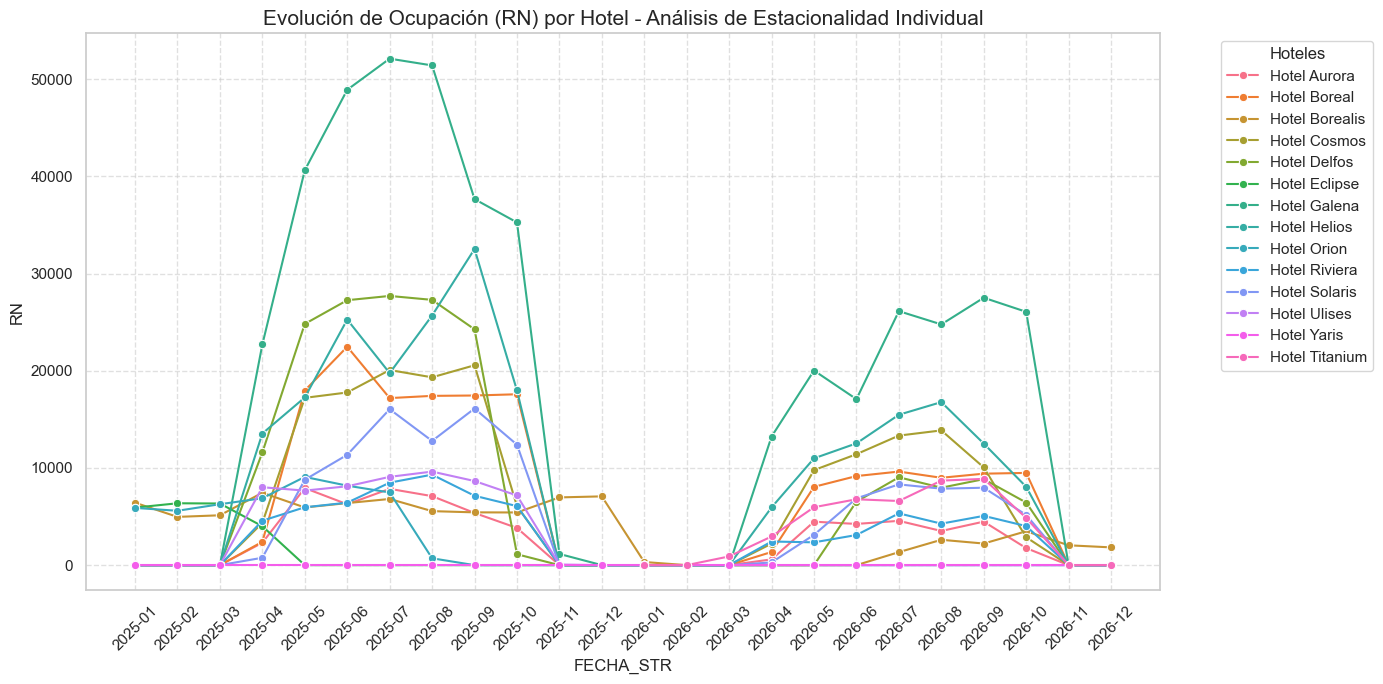

In [35]:

# Estacionalidad por hotel
reporte_discrepancias_inact = detalle_periodos[
    ((detalle_periodos['SOLO BUDGET (Falta en Real)'] != "") &  
     (detalle_periodos['SOLO BUDGET (Falta en Real)'] != "2026-04, 2026-05, 2026-06, 2026-07, 2026-08, 2026-09, 2026-10, 2026-11, 2026-12")) | 

    (detalle_periodos['SOLO REAL (Falta en Budget)'] != "") |
    (detalle_periodos['INACTIVOS'] != "")
]

pnl_eda_estacionalidad= pnl_eda[pnl_eda['HOTEL'].isin(reporte_discrepancias_inact.index)].copy()
hotel_monthly_rn = pnl_eda_estacionalidad.groupby(['FECHA_STR', 'HOTEL'])['RN'].sum().reset_index()

plt.figure(figsize=(14, 7))
sns.lineplot(data=hotel_monthly_rn, x='FECHA_STR', y='RN', hue='HOTEL', marker='o')
plt.xticks(rotation=45)
plt.title('Evolución de Ocupación (RN) por Hotel - Análisis de Estacionalidad Individual', fontsize=15)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title='Hoteles', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

Existen hoteles con operatividad estacional; por ejemplo, Aurora y Boreal solo abren de abril a octubre. Por otro lado, Yaris no registra actividad real en el sistema y Ulises parece haber cerrado permanentemente considerando como actividad "RN" 

## Merge audit 

Se realiza una auditoría de integridad sobre el merge de ambas tablas, analizando la coincidencia de registros (inner join) y detectando valores huérfanos o discrepancias en las uniones externas."

In [36]:
hoteles_pnl = set(pnl_eda['HOTEL'].str.strip().str.upper().unique())
hoteles_maestra = set(hotels_eda['HOTEL'].str.strip().str.upper().unique())

no_pnl = hoteles_pnl - hoteles_maestra
no_master = hoteles_maestra - hoteles_pnl

print(f"Hoteles en P&L: {len(hoteles_pnl)}")
print(f"Hoteles en Maestra: {len(hoteles_maestra)}")
print(f"Hoteles en P&L que faltan en Maestra: {len(no_master)}")
if no_master: print(f"Lista: {no_master}")
print(f"Hoteles en Maestra que faltan en P&L  {len(no_pnl)}")
if no_pnl: print(f"Lista: {no_pnl}")


Hoteles en P&L: 29
Hoteles en Maestra: 29
Hoteles en P&L que faltan en Maestra: 6
Lista: {'HOTEL ESTRELLA', 'HOTEL GARDEN', 'HOTEL PALACIO', 'HOTEL MIRADOR REAL', 'HOTEL VEGA MAR', 'HOTEL SUITES'}
Hoteles en Maestra que faltan en P&L  6
Lista: {'HOTEL MIRADOR', 'HOTEL ORION', 'HOTEL JUPITER', 'HOTEL PRISMA', 'HOTEL ALHAMBRA', 'HOTEL QUASAR'}


## Analisis de costos

In [37]:
# Columnas de gastos operativos
cost_cols = ['ROOMS_PERSONNEL', 'ROOMS_OTHER_EXPENSES', 'ROOMS_OPEX',
             'FOOD_COST', 'BEVERAGE_COST','FB_COST', 'FB_PERSONNEL',
             'FB_OTHER_EXPENSES','FB_OPEX','OPERATING_EXPENSES',
             'UNDISTRIB_OPEX']

# Conteo de registros donde el gasto es positivo (Anomalía)
def generar_resumen(df, etiqueta):
    print(f"\n--- RESUMEN: {etiqueta} ---")
    for col in cost_cols:
        positivos = df[df[col] > 0][col]
        num_casos = len(positivos)
        if num_casos > 0:
            print(f"-> {col:20} | Casos: {num_casos:4} | Rango: [{positivos.min():,.2f} a {positivos.max():,.2f}]")
        else:
            print(f"-> {col:20} | Sin anomalías (>0)")

# Resumen Total
generar_resumen(pnl_eda, "TOTAL")

#Resumen segmentado por Escenario
for escenario in pnl_eda['ESCENARIO'].unique():
    df_segmento = pnl_eda[pnl_eda['ESCENARIO'] == escenario]
    generar_resumen(df_segmento, escenario)

#Filtrado global para inspección
anomalias_costos = pnl_eda[pnl_eda[cost_cols].gt(0).any(axis=1)]

if not anomalias_costos.empty:
    display(anomalias_costos[['HOTEL', 'ANIO', 'MES', 'ESCENARIO'] + cost_cols].head())


--- RESUMEN: TOTAL ---
-> ROOMS_PERSONNEL      | Casos:   11 | Rango: [1.20 a 12,066.08]
-> ROOMS_OTHER_EXPENSES | Casos:   10 | Rango: [7.45 a 390,728.68]
-> ROOMS_OPEX           | Casos:    9 | Rango: [7.43 a 106,721.29]
-> FOOD_COST            | Casos:   19 | Rango: [0.61 a 3,782.99]
-> BEVERAGE_COST        | Casos:   13 | Rango: [17.03 a 3,986.33]
-> FB_COST              | Casos:   24 | Rango: [0.61 a 4,721.99]
-> FB_PERSONNEL         | Casos:    3 | Rango: [6,743.91 a 17,282.53]
-> FB_OTHER_EXPENSES    | Casos:    6 | Rango: [0.01 a 1,125.71]
-> FB_OPEX              | Casos:    1 | Rango: [0.03 a 0.03]
-> OPERATING_EXPENSES   | Casos:    5 | Rango: [220.47 a 5,829.89]
-> UNDISTRIB_OPEX       | Casos:    6 | Rango: [189.36 a 122,000.87]

--- RESUMEN: BUDGET ---
-> ROOMS_PERSONNEL      | Casos:    6 | Rango: [120.52 a 5,642.00]
-> ROOMS_OTHER_EXPENSES | Sin anomalías (>0)
-> ROOMS_OPEX           | Casos:    2 | Rango: [3,349.70 a 5,593.20]
-> FOOD_COST            | Sin anomalías (>

,HOTEL,ANIO,MES,ESCENARIO,ROOMS_PERSONNEL,ROOMS_OTHER_EXPENSES,ROOMS_OPEX,FOOD_COST,BEVERAGE_COST,FB_COST,FB_PERSONNEL,FB_OTHER_EXPENSES,FB_OPEX,OPERATING_EXPENSES,UNDISTRIB_OPEX
23,Hotel Alhambra,2025,12,REAL,-284007.38,390728.68,106721.29,-724531.68,-298885.54,-1023417.22,-505474.08,-196872.48,-1725763.78,-1619042.48,-2261498.02
50,Hotel Aurora,2025,2,BUDGET,120.52,-4795.96,-4675.44,0.00,0.00,0.00,-6185.62,-6366.30,-12551.92,-17227.36,-125725.71
51,Hotel Aurora,2025,2,REAL,0.00,-7264.26,-7264.26,3292.74,0.00,3292.74,-8444.46,-8484.21,-13635.93,-20900.19,-163273.75
53,Hotel Aurora,2025,3,REAL,-7765.52,-940.37,-8705.89,0.00,1059.38,1059.38,-9283.46,-5361.32,-13585.41,-22291.30,-101219.77
69,Hotel Aurora,2025,11,REAL,-2491.26,-29084.02,-31575.28,3782.99,-101.82,3681.17,-12802.39,-9803.88,-18925.10,-50500.38,-160587.17


## AR (Average Rate: Tarifa promedio por habitación.) -Analysis



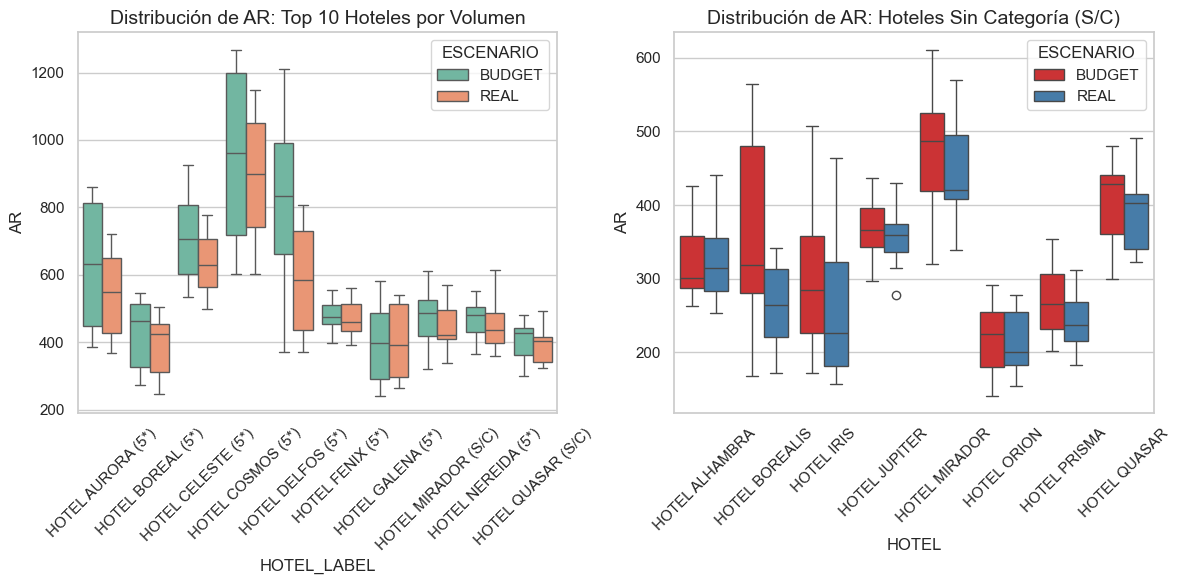

In [52]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

pnl_eda["HOTEL"] = pnl_eda["HOTEL"].str.strip().str.upper()
hotels_eda["HOTEL"] = hotels_eda["HOTEL"].str.strip().str.upper()
pnl_full = pnl_eda.merge(hotels_eda, on="HOTEL", how="left")

top_hotels_ar = pnl_full.groupby('HOTEL')['AR'].mean().nlargest(10).index
df_top_ar = pnl_full[pnl_full['HOTEL'].isin(top_hotels_ar)].copy()
df_top_ar['HOTEL_LABEL'] = df_top_ar['HOTEL'] + " (" + df_top_ar['CATEGORIA'].fillna('S/C') + ")"

# Sin Estrellas 
df_sin_estrellas = pnl_full[pnl_full['CATEGORIA'].isna() | (pnl_full['CATEGORIA'] == 'S/C')].copy()

fig, (ax1, ax2) = plt.subplots(1, 2)

# Gráfica 1: Top 10 Volumen AR por Hotel y Escenario
sns.boxplot(
    data=df_top_ar, 
    x='HOTEL_LABEL', 
    y='AR', 
    hue='ESCENARIO', 
    palette='Set2', 
    ax=ax1
)
ax1.set_title('Distribución de AR: Top 10 Hoteles por Volumen', fontsize=14)
ax1.tick_params(axis='x', rotation=45)

# Gráfica 2: Hoteles Sin Categoría (S/C)
sns.boxplot(
    data=df_sin_estrellas, 
    x='HOTEL', 
    y='AR', 
    hue='ESCENARIO', 
    palette='Set1', 
    ax=ax2
)
ax2.set_title('Distribución de AR: Hoteles Sin Categoría (S/C)', fontsize=14)
ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

### Analisis de signos esperados por variables

In [53]:
def stats(df, group_by=None):
    
    def get_stats_num(df_in):
        numeric_data = df_in.select_dtypes(include='number')
        if group_by:
            cols_to_drop = [group_by] if isinstance(group_by, str) else group_by
            numeric_data = numeric_data.drop(columns=[c for c in cols_to_drop if c in numeric_data.columns])
        if numeric_data.empty:
            return pd.DataFrame() 
        
        stats_num = numeric_data.describe(percentiles=[0.01,0.1, 0.25, 0.5, 0.75, 0.95, 0.99])
        stats_num.loc['range'] = stats_num.loc['max'] - stats_num.loc['min']
        stats_num.loc['CV'] = stats_num.loc['std'] / np.abs(stats_num.loc['mean'].replace(0, np.nan))
        stats_num.loc['skew'] = numeric_data.skew()
        
        outliers_percentages = {}
        for col in numeric_data.columns:
            q1, q3 = numeric_data[col].quantile([0.25, 0.75])
            iqr = q3 - q1
            lower_bound = q1 - 1.5 * iqr
            upper_bound = q3 + 1.5 * iqr
            
            outliers = numeric_data[(numeric_data[col] < lower_bound) | (numeric_data[col] > upper_bound)]
            outliers_percentages[col] = round(len(outliers) / len(df_in) * 100, 2)
        
        stats_num.loc['outliers_%'] = pd.Series(outliers_percentages)

        total = len(df_in)
        stats_num.loc['positives_count'] = (numeric_data > 0).sum()
        stats_num.loc['negatives_count'] = (numeric_data < 0).sum()
        stats_num.loc['zeros_count'] = (numeric_data == 0).sum()
        stats_num.loc['positives_%'] = round((numeric_data > 0).sum() / total * 100, 2)
        stats_num.loc['negatives_%'] = round((numeric_data < 0).sum() / total * 100, 2)
        stats_num.loc['zeros_%'] = round((numeric_data == 0).sum() / total * 100, 2)
        return stats_num.T
    
    def get_stats_cat(df_in):
        categorical_data = df_in.select_dtypes(include=['object', 'string', 'category'])
        if categorical_data.empty:
            return pd.DataFrame()
        
        cat_list = [] 
        for col in categorical_data.columns:
            col_data = categorical_data[col]
            v_count = col_data.value_counts(dropna=False)
            res = {
                'metrica': col, 
                'count': len(col_data),
                'unique': col_data.nunique(),
                'top': col_data.mode().iloc[0] if not col_data.mode().empty else np.nan,
                'freq_top_%': round((v_count.iloc[0] / len(col_data)) * 100, 2) if not v_count.empty else 0
            }
            cat_list.append(res)
        
        return pd.DataFrame(cat_list).set_index('metrica').T
    # Grouping logic
    is_valid = False
    if isinstance(group_by, str) and group_by in df.columns:
        is_valid = True
    elif isinstance(group_by, list) and all(c in df.columns for c in group_by):
        is_valid = True

    if is_valid:
        grouped = df.groupby(group_by) 
        return (grouped.apply(get_stats_num, include_groups=False), 
                grouped.apply(get_stats_cat, include_groups=False))
    
    return get_stats_num(df), get_stats_cat(df)

In [55]:
# Reglas de validación: 1 para positivo, -1 para negativo, 0 para mixto
VALIDATION_RULES = {
    # Unidades e Ingresos (Deben ser >= 0)
    "RN": 1, "HABITACIONES": 1, "ROOMS_REV_ALOJAMIENTO":1,
    "ROOMS_REV_UPGRADES": 1, "ROOMS_REV_OTROS":1,
    "ROOMS_REVENUE": 1, "FOOD_REVENUE": 1, 
    "BEVERAGE_REVENUE": 1,  "BANQUETS_REVENUE": 1,"FB_PENSION":1,
    "DAY_PASS":1,"FB_REVENUE":1, "OTHER_DEPT_REVENUE":1,
    "MISC_INCOME" :1, "OPERATING_REVENUE": 1, "AR": 1, 
    "ROOMS_REV_UPGRADES": 1, 
    
    
    # Gastos (Deben ser <= 0 en tu dataset)
    "ROOMS_PERSONNEL": -1,"ROOMS_OTHER_EXPENSES":-1, "ROOMS_OPEX": -1,
    "FOOD_COST": -1, "BEVERAGE_COST": -1, "FB_COST":-1, "FB_PERSONNEL": -1,
    "FB_OTHER_EXPENSES":-1,"FB_OPEX": -1, "OPERATING_EXPENSES":-1,
    "UNDISTRIB_OPEX": -1,
        
    # Resultados (Pueden ser cualquiera)
    "GOP": 0, "ROOMS_PROFIT": 0, "FB_PROFIT": 0,"TOTAL_DEPT_PROFIT":0
}

def audit_signos(res_num_df):
    """Analize signs"""
    audit_results = res_num_df.copy()
    status = []
    
    for metric in audit_results.index:
        # Extraer el nombre de la métrica si el índice es agrupado (tupla)
        nombre_metrica = metric[1] if isinstance(metric, tuple) else metric
        rule = VALIDATION_RULES.get(nombre_metrica, 0)
        
        v_min = audit_results.loc[metric, 'min']
        v_max = audit_results.loc[metric, 'max']
        
        if rule == 1: 
            if v_min < -0.01: # Error tolerance
                status.append("ERROR: Contiene Negativos")
            else:
                status.append("OK")
        elif rule == -1: # Esperado Negativo
            if v_max > 0.01:
                status.append("ERROR: Contiene Positivos")
            else:
                status.append("OK")
        else:
            status.append("MIXTO: (Normal)")
            
    audit_results['AUDIT_STATUS'] = status
    return audit_results


res_num, _ = stats(pnl_eda)
res_num_filtered = res_num[res_num.index.isin(VALIDATION_RULES.keys())]
pnl_audit_report = audit_signos(res_num_filtered)

pnl_budget=pnl_eda[pnl_eda["ESCENARIO"]=="BUDGET"]
pnl_real=pnl_eda[pnl_eda["ESCENARIO"]=="REAL"]
res_budget,_ = stats(pnl_budget)
audit_budget=audit_signos(res_budget)

res_real,_ = stats(pnl_real)
audit_real=audit_signos(res_real)

res_num_hotel, _ = stats(pnl_eda, group_by=["HOTEL"])
audit_hotel = audit_signos(res_num_hotel)

print("REPORTE DE INTEGRIDAD DE SIGNOS:")
display(pnl_audit_report[['min', 'max', 'positives_%','negatives_%', 'zeros_%', 'AUDIT_STATUS']])

#Save Audit Status
with pd.ExcelWriter('Hoteles_EDA_Audit.xlsx', engine='openpyxl') as writer:
    pnl_audit_report.to_excel(writer, sheet_name='Global Audit')
    audit_hotel.to_excel(writer, sheet_name='Hotels Audit')
    audit_real.to_excel(writer, sheet_name='Real')
    audit_budget.to_excel(writer, sheet_name='Budget')


REPORTE DE INTEGRIDAD DE SIGNOS:


,min,max,positives_%,negatives_%,zeros_%,AUDIT_STATUS
RN,0.00,69026.00,64.12,0.00,35.88,OK
HABITACIONES,0.00,78189.00,64.20,0.00,35.80,OK
ROOMS_REV_ALOJAMIENTO,-2158971.98,14660887.57,67.67,1.77,30.56,ERROR: Contiene Negativos
ROOMS_REV_UPGRADES,-5978.77,875473.37,64.81,0.31,34.88,ERROR: Contiene Negativos
ROOMS_REV_OTROS,-3012.24,28182.95,12.42,0.31,87.27,ERROR: Contiene Negativos
ROOMS_REVENUE,-2154558.59,14851444.84,67.67,1.77,30.56,ERROR: Contiene Negativos
FOOD_REVENUE,-371312.23,2025972.19,64.43,1.39,34.18,ERROR: Contiene Negativos
BEVERAGE_REVENUE,-10209.29,1966038.60,62.27,0.31,37.42,ERROR: Contiene Negativos
BANQUETS_REVENUE,-63865.89,472193.59,45.22,1.31,53.47,ERROR: Contiene Negativos
FB_PENSION,-1238350.61,5205072.98,64.89,0.69,34.41,ERROR: Contiene Negativos


### Validaciones de integridad contable

Un Profit no puede ser positivo si el Revenue es 0 (salvo ajustes contables)

ROOMS_REVENUE=ROOMS_REV_ALOJAMIENTO+ROOMS_REV_UPGRADES+ROOMS_REV_OTROS
FB_REVENUE=FOOD_REVENUE+BEVERAGE_REVENUE+BANQUETS_REVENUE+FB_PENSION+DAY_PASS



In [91]:
# Validaciones de Integridad Contable
validaciones = {
   
    # Cuadre de ROOMS_REVENUE (Margen de 0.01 por redondeos)
    "DIFF_ROOMS": lambda d: d['ROOMS_REVENUE'] - (d['ROOMS_REV_ALOJAMIENTO'] + d['ROOMS_REV_UPGRADES'] + d['ROOMS_REV_OTROS']),
    
    # Cuadre de FB_REVENUE
    "DIFF_REV_FB": lambda d: d['FB_REVENUE'] - (d['FOOD_REVENUE'] + d['BEVERAGE_REVENUE'] + 
                                            d['BANQUETS_REVENUE'] + d['FB_PENSION'] + d['DAY_PASS']),
    
    # Cuadre FB_COST
    "DIFF_COST_FB": lambda d: d['FB_COST'] - (d['FOOD_COST'] + d['BEVERAGE_COST']),

    "DIFF_OPERATING_EXPENSES": lambda d:d['OPERATING_EXPENSES']- (d['ROOMS_OPEX'] + d['FB_OPEX']),

    "DIFF_ROOMS_PROFIT"  : lambda d:   d['ROOMS_PROFIT'] - (d['ROOMS_REVENUE']+d['ROOMS_PERSONNEL'] + d['ROOMS_OTHER_EXPENSES']),

    "DIFF_OPERATING_REVENUE"  :lambda d: d['OPERATING_REVENUE']-(d['OTHER_DEPT_REVENUE']+d['MISC_INCOME']+ d['ROOMS_REVENUE'] + d['FB_REVENUE']),

    "DIFF_FB_PROFIT": lambda d: d['FB_PROFIT']- (d['FB_REVENUE']+d['FB_COST']+ d['FB_PERSONNEL']+d['FB_OTHER_EXPENSES'])
}

pnl_assert =pnl_eda.copy()
# 3. Aplicación al DataFrame
pnl_assert = pnl_assert.assign(**validaciones)

tolerancia = 0.1

#Discrepancias
reporte_errores = {
    "Descuadre en Rooms Revenue": pnl_assert[abs(pnl_assert['DIFF_ROOMS']) > tolerancia].shape[0],
    "Descuadre en FB Revenue": pnl_assert[abs(pnl_assert['DIFF_REV_FB']) > tolerancia].shape[0],
    "Descuadre en FB Cost": pnl_assert[abs(pnl_assert['DIFF_COST_FB']) > tolerancia].shape[0],
    "Descuadre en OPERATING_EXPENSES" : pnl_assert[abs(pnl_assert['DIFF_OPERATING_EXPENSES']) > tolerancia].shape[0],
    "Descuadre en ROOMS_PROFIT" : pnl_assert[abs(pnl_assert['DIFF_ROOMS_PROFIT']) > tolerancia].shape[0] ,
    "Descuadre en OPERATING_REVENUE": pnl_assert[abs(pnl_assert['DIFF_OPERATING_REVENUE']) > tolerancia].shape[0],
    "Descuadre en FB_PROFIT": pnl_assert[abs(pnl_assert['DIFF_FB_PROFIT']) > tolerancia].shape[0]
}

#Resumen
print("--- RESUMEN DE VALIDACIONES ---")
for validacion, cantidad in reporte_errores.items():
    estado = "❌ ERROR" if cantidad > 0 else "✅ OK"
    print(f"{estado} | {validacion}: {cantidad} registros encontrados.")


--- RESUMEN DE VALIDACIONES ---
✅ OK | Descuadre en Rooms Revenue: 0 registros encontrados.
✅ OK | Descuadre en FB Revenue: 0 registros encontrados.
✅ OK | Descuadre en FB Cost: 0 registros encontrados.
✅ OK | Descuadre en OPERATING_EXPENSES: 0 registros encontrados.
✅ OK | Descuadre en ROOMS_PROFIT: 0 registros encontrados.
✅ OK | Descuadre en OPERATING_REVENUE: 0 registros encontrados.
✅ OK | Descuadre en FB_PROFIT: 0 registros encontrados.


In [81]:
errores_encontrados = pnl_assert[abs(pnl_assert['DIFF_ROOMS_PROFIT']>0.1)][['DIFF_ROOMS_PROFIT','HOTEL','ANIO','MES']]
errores_encontrados

,DIFF_ROOMS_PROFIT,HOTEL,ANIO,MES
0,4678792.40,HOTEL ALHAMBRA,2025,1
1,3984026.70,HOTEL ALHAMBRA,2025,1
2,3400747.39,HOTEL ALHAMBRA,2025,2
3,2806163.05,HOTEL ALHAMBRA,2025,2
4,2419712.67,HOTEL ALHAMBRA,2025,3
...,...,...,...,...
1286,352436.47,HOTEL ZENITH,2026,8
1288,139367.54,HOTEL ZENITH,2026,9
1290,202651.65,HOTEL ZENITH,2026,10
1292,271472.40,HOTEL ZENITH,2026,11
